# Testing the Realized-Skew Risk Premium in Futures Markets

## Research question

Does recent realized skewness predict subsequent futures returns, and can a skew strategy improve the risk-adjusted performance of trend following?

This notebook implements a transparent adaptation of Robert Carver's Strategy 24, “Skew — a case study.”

In [21]:
adjusted_folder = RAW / "adjusted"
multiple_folder = RAW / "multiple"

adjusted_folder.mkdir(exist_ok=True)
multiple_folder.mkdir(exist_ok=True)


def download_file(url: str, destination: Path) -> None:
    if destination.exists():
        print("Already downloaded:", destination.name)
        return

    response = requests.get(url, timeout=180)
    response.raise_for_status()
    destination.write_bytes(response.content)

    print("Downloaded:", destination.name)


for market in MARKETS:
    download_file(
        url=f"{BASE_URL}/adjusted_prices_csv/{market}.csv",
        destination=adjusted_folder / f"{market}.csv",
    )

    download_file(
        url=f"{BASE_URL}/multiple_prices_csv/{market}.csv",
        destination=multiple_folder / f"{market}.csv",
    )

Already downloaded: SP500.csv
Already downloaded: SP500.csv
Already downloaded: NASDAQ.csv
Already downloaded: NASDAQ.csv
Already downloaded: US2.csv
Already downloaded: US2.csv
Already downloaded: US5.csv
Already downloaded: US5.csv
Already downloaded: US10.csv
Already downloaded: US10.csv
Already downloaded: US20.csv
Already downloaded: US20.csv
Already downloaded: CRUDE_W.csv
Already downloaded: CRUDE_W.csv
Already downloaded: GOLD.csv
Already downloaded: GOLD.csv
Already downloaded: COPPER.csv
Already downloaded: COPPER.csv
Already downloaded: CORN.csv
Already downloaded: CORN.csv
Already downloaded: WHEAT.csv
Already downloaded: WHEAT.csv
Already downloaded: SOYBEAN.csv
Already downloaded: SOYBEAN.csv
Already downloaded: EUR.csv
Already downloaded: EUR.csv
Already downloaded: JPY.csv
Already downloaded: JPY.csv
Already downloaded: GBP.csv
Already downloaded: GBP.csv


In [22]:
adjusted_example = pd.read_csv(
    adjusted_folder / "SP500.csv",
    nrows=5,
)

multiple_example = pd.read_csv(
    multiple_folder / "SP500.csv",
    nrows=5,
)

display(adjusted_example)
display(multiple_example)

,DATETIME,price
0,1982-09-14 23:00:00,682.65
1,1982-09-15 23:00:00,683.15
2,1982-09-16 23:00:00,682.50
3,1982-09-17 23:00:00,681.60
4,1982-09-20 23:00:00,682.40


,DATETIME,CARRY,CARRY_CONTRACT,PRICE,PRICE_CONTRACT,FORWARD,FORWARD_CONTRACT
0,1982-09-14 23:00:00,NaN,19830300,123.70,19821200,NaN,19830300
1,1982-09-15 23:00:00,NaN,19830300,124.20,19821200,NaN,19830300
2,1982-09-16 23:00:00,NaN,19830300,123.55,19821200,NaN,19830300
3,1982-09-17 23:00:00,NaN,19830300,122.65,19821200,NaN,19830300
4,1982-09-20 23:00:00,NaN,19830300,123.45,19821200,NaN,19830300


In [23]:
def read_daily_last(
    path: Path,
    value_column: str,
) -> pd.Series:

    frame = pd.read_csv(
        path,
        usecols=["DATETIME", value_column],
    )

    frame["DATETIME"] = pd.to_datetime(
        frame["DATETIME"],
        errors="coerce",
    )

    frame[value_column] = pd.to_numeric(
        frame[value_column],
        errors="coerce",
    )

    frame = frame.dropna(
        subset=["DATETIME", value_column]
    )

    frame["date"] = (
        frame["DATETIME"].dt.normalize()
    )

    daily = (
        frame.groupby("date")[value_column]
        .last()
        .sort_index()
    )

    return daily

In [24]:
def calculate_market_returns(
    market: str,
) -> tuple[pd.Series, int]:

    adjusted = read_daily_last(
        adjusted_folder / f"{market}.csv",
        "price",
    )

    current_contract = read_daily_last(
        multiple_folder / f"{market}.csv",
        "PRICE",
    )

    combined = pd.concat(
        [
            adjusted.rename("adjusted"),
            current_contract.rename("current_contract"),
        ],
        axis=1,
    ).sort_index()

    combined["current_contract"] = (
        combined["current_contract"].ffill()
    )

    returns = (
        combined["adjusted"].diff()
        / combined["current_contract"].abs()
    )

    # Identify likely bad price observations using only prior data.
    trailing_volatility = (
        returns.ewm(
            span=35,
            min_periods=20,
        )
        .std()
        .shift(1)
    )

    suspected_error = (
        returns.abs()
        > 12 * trailing_volatility
    )

    number_removed = int(suspected_error.sum())

    returns = returns.mask(suspected_error)

    return returns.rename(market), number_removed

return_series = []
cleaning_results = []

for market in MARKETS:
    market_return, removed = calculate_market_returns(market)

    return_series.append(market_return)

    cleaning_results.append({
        "market": market,
        "suspected_errors_removed": removed,
    })

returns = pd.concat(
    return_series,
    axis=1,
).loc["1990-01-01":]

cleaning_results = pd.DataFrame(cleaning_results)

display(cleaning_results)
display(returns.tail())

returns.to_csv(
    PROCESSED / "futures_returns.csv"
)

C:\Users\jacob\AppData\Local\Temp\ipykernel_35172\3912823774.py:66: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  returns = pd.concat(


,market,suspected_errors_removed
0,SP500,2
1,NASDAQ,0
2,US2,0
3,US5,0
4,US10,0
5,US20,0
6,CRUDE_W,1
7,GOLD,0
8,COPPER,0
9,CORN,0


,SP500,NASDAQ,US2,US5,US10,US20,CRUDE_W,GOLD,COPPER,CORN,WHEAT,SOYBEAN,EUR,JPY,GBP
date,,,,,,,,,,,,,,,
2024-03-22,-0.003356,-0.000862,0.000916,0.002552,0.004369,0.007294,-0.003936,-0.007815,-0.016023,-0.003156,0.011959,-0.014532,-0.005442,0.001345,-0.005319
2024-03-25,-0.001704,-0.001632,-0.000725,-0.001753,-0.002826,-0.004448,0.013078,0.002962,0.003959,-0.001053,0.004107,0.009802,0.002897,-0.000299,0.003717
2024-03-26,-0.001565,-0.002895,-0.000115,0.000146,0.000565,0.001307,-0.007041,0.002998,-0.001363,-0.014423,-0.013317,-0.006507,-0.000322,-0.000449,-0.000871
2024-03-27,0.006735,0.001378,0.000382,0.001240,0.002255,0.005716,0.004285,0.006365,0.002102,-0.012439,0.004144,-0.006337,-0.001151,0.000897,0.000396
2024-03-28,-0.000754,-0.002193,-0.001146,-0.001607,-0.001411,-0.000520,0.008496,0.017474,-0.000371,0.032444,0.014297,0.002318,-0.003281,-0.000673,-0.000792


In [25]:
coverage = pd.DataFrame({
    "start": returns.apply(
        lambda column: column.first_valid_index()
    ),
    "end": returns.apply(
        lambda column: column.last_valid_index()
    ),
    "observations": returns.count(),
})

display(coverage)

coverage.to_csv(
    OUTPUTS / "data_coverage.csv"
)

,start,end,observations
SP500,1990-01-02,2024-03-28,8867
NASDAQ,1999-12-15,2024-03-28,6287
US2,2000-03-03,2024-03-28,6192
US5,1990-01-02,2024-03-28,8710
US10,1990-01-02,2024-03-28,8704
US20,1990-01-02,2024-03-28,8709
CRUDE_W,1990-10-17,2024-03-28,8602
GOLD,1990-01-02,2024-03-28,8687
COPPER,1995-09-05,2024-03-28,7621
CORN,1990-01-02,2024-03-28,8689


Note: pysystemtrade's bundled futures data is a static snapshot ending March 2024.

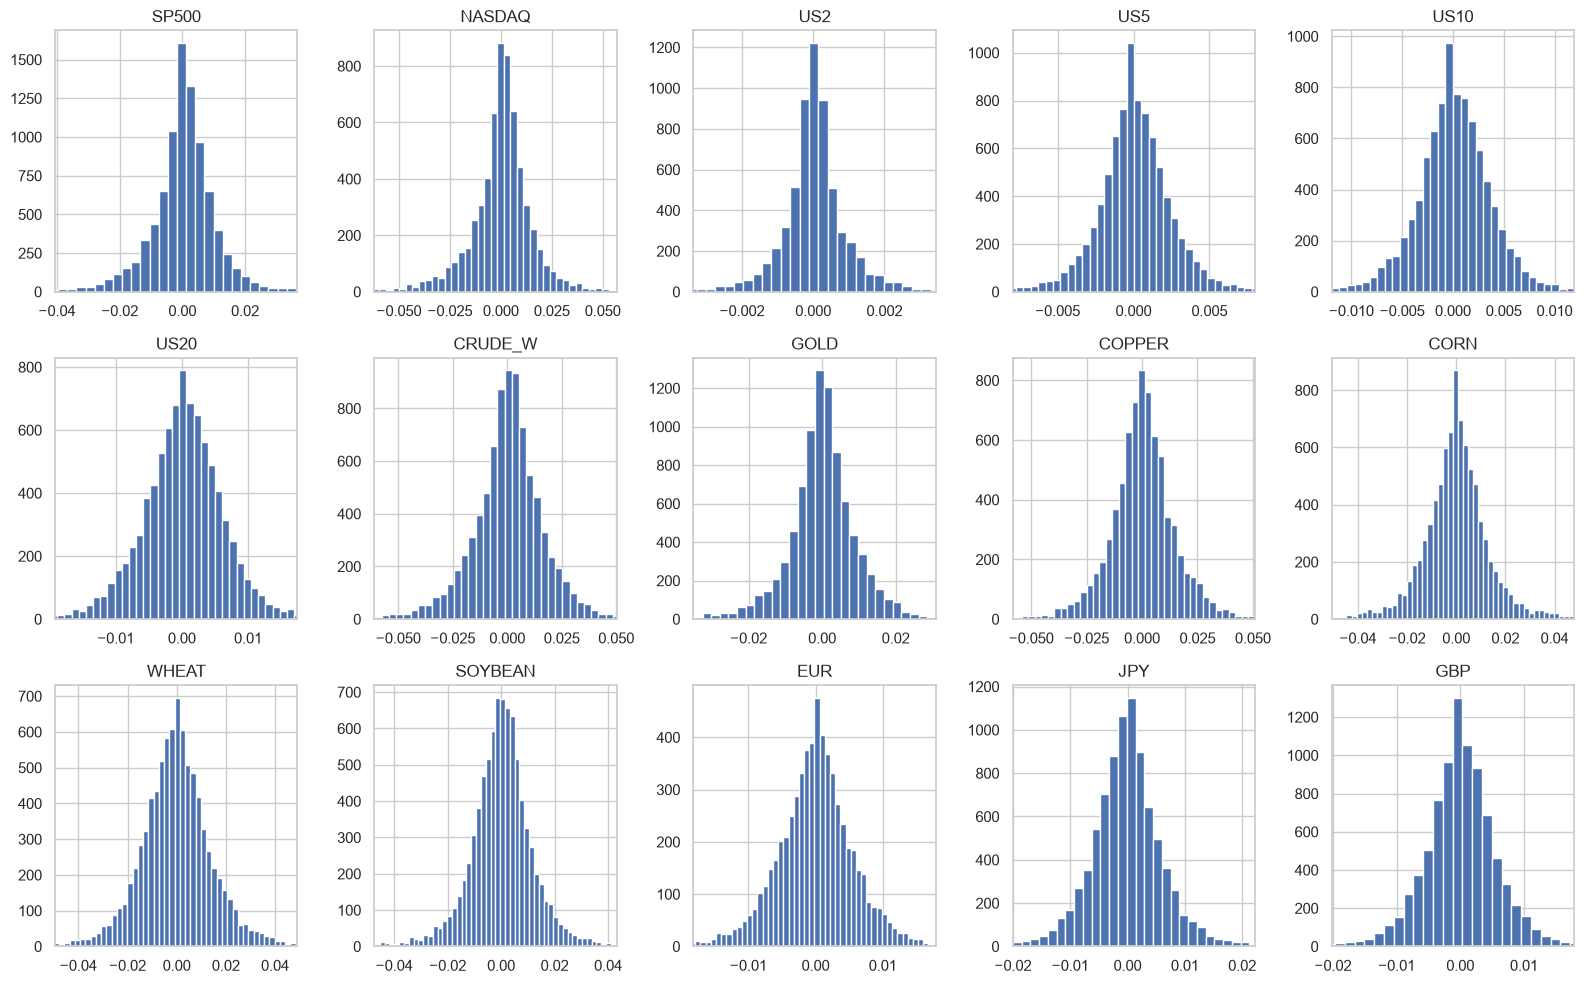

In [26]:
fig, axes = plt.subplots(
    3,
    5,
    figsize=(16, 10),
)

for market, axis in zip(MARKETS, axes.flatten()):
    returns[market].dropna().hist(
        bins=80,
        ax=axis,
    )

    axis.set_title(market)
    axis.set_xlim(
        returns[market].quantile(0.005),
        returns[market].quantile(0.995),
    )

plt.tight_layout()
plt.show()

In [27]:
def calculate_skew_signal(
    returns: pd.DataFrame,
    lookback: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    rolling_skew = returns.rolling(
        window=lookback,
        min_periods=int(lookback * 0.80),
    ).skew()

    cross_sectional_rank = rolling_skew.rank(
        axis=1,
        pct=True,
    )

    # Negative skew becomes a positive signal.
    raw_signal = (
        -(cross_sectional_rank - 0.5) * 2
    )

    smoothing_span = max(
        5,
        round(lookback / 10),
    )

    smoothed_signal = raw_signal.ewm(
        span=smoothing_span,
        min_periods=smoothing_span,
    ).mean()

    return rolling_skew, smoothed_signal


skew_126, signal_126 = calculate_skew_signal(
    returns,
    126,
)

skew_252, signal_252 = calculate_skew_signal(
    returns,
    252,
)

display(skew_252.tail())
display(signal_252.tail())

,SP500,NASDAQ,US2,US5,US10,US20,CRUDE_W,GOLD,COPPER,CORN,WHEAT,SOYBEAN,EUR,JPY,GBP
date,,,,,,,,,,,,,,,
2024-03-22,-0.035360,-0.168953,0.446000,0.394762,0.306132,0.061907,-0.525047,0.386745,-0.115429,0.021457,0.561691,0.615109,0.271532,0.125585,0.173218
2024-03-25,-0.027007,-0.171051,0.460542,0.410774,0.322178,0.074798,-0.588332,0.392372,-0.126804,0.023778,0.562397,0.615070,0.272732,0.130855,0.173096
2024-03-26,-0.030974,-0.170383,0.461477,0.417387,0.329891,0.080669,-0.577102,0.373108,-0.123742,0.023968,0.565729,0.614745,0.283036,0.138923,0.180936
2024-03-27,-0.046264,-0.179400,0.465301,0.414897,0.327104,0.079792,-0.586419,0.362550,-0.122688,0.033449,0.556728,0.616915,0.279619,0.143495,0.173618
2024-03-28,-0.038619,-0.169414,0.465318,0.419356,0.332136,0.082404,-0.592806,0.368374,-0.115845,0.046291,0.541731,0.609874,0.292152,0.136150,0.173594


,SP500,NASDAQ,US2,US5,US10,US20,CRUDE_W,GOLD,COPPER,CORN,WHEAT,SOYBEAN,EUR,JPY,GBP
date,,,,,,,,,,,,,,,
2024-03-22,0.468384,0.660440,-0.744295,-0.667548,-0.338295,0.098149,0.866665,-0.592078,0.670011,0.329212,-0.741307,-0.913997,-0.100344,0.053578,-0.048576
2024-03-25,0.468252,0.666047,-0.743452,-0.662352,-0.337913,0.105984,0.866665,-0.582431,0.664626,0.329529,-0.750950,-0.920612,-0.108009,0.054585,-0.049968
2024-03-26,0.468130,0.671223,-0.742674,-0.657556,-0.337561,0.113216,0.866665,-0.573526,0.659654,0.329821,-0.759851,-0.926719,-0.115086,0.055514,-0.051252
2024-03-27,0.468017,0.676000,-0.741955,-0.653128,-0.337235,0.119892,0.866665,-0.565306,0.655066,0.330091,-0.768068,-0.932356,-0.121617,0.056372,-0.052438
2024-03-28,0.467914,0.680411,-0.741292,-0.649042,-0.336935,0.126054,0.866665,-0.557719,0.650830,0.330341,-0.775652,-0.937559,-0.127647,0.057164,-0.053532


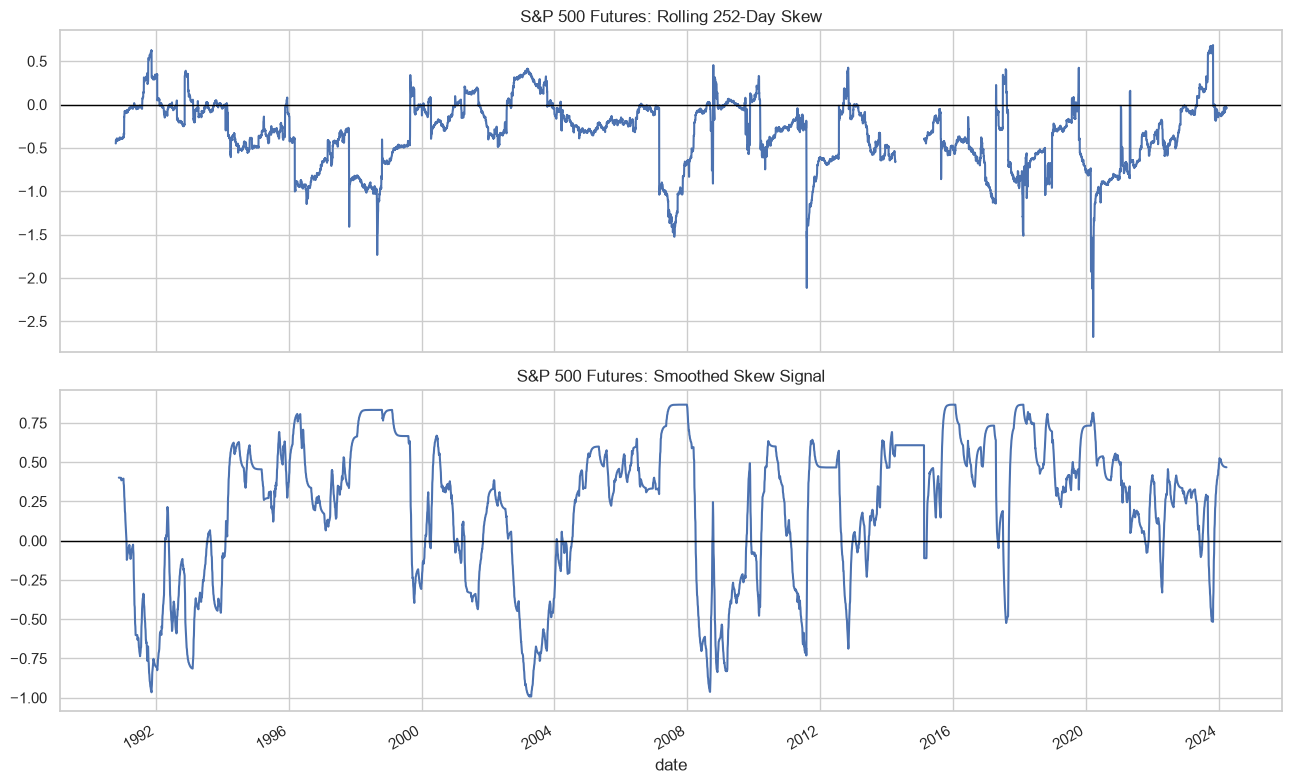

In [28]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(13, 8),
    sharex=True,
)

skew_252["SP500"].plot(
    ax=axes[0],
    title="S&P 500 Futures: Rolling 252-Day Skew",
)

signal_252["SP500"].plot(
    ax=axes[1],
    title="S&P 500 Futures: Smoothed Skew Signal",
)

axes[0].axhline(0, color="black", linewidth=1)
axes[1].axhline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

,SP500,NASDAQ,US2,US5,US10,US20,CRUDE_W,GOLD,COPPER,CORN,WHEAT,SOYBEAN,EUR,JPY,GBP
date,,,,,,,,,,,,,,,
2024-03-22,0.172550,0.164142,-1.532183,-0.655101,-0.243590,0.039521,0.211976,-0.192854,0.150774,0.100024,-0.132714,-0.275718,-0.073704,0.024822,-0.030326
2024-03-25,0.175320,0.171328,-1.549174,-0.648360,-0.238134,0.042119,0.217490,-0.186625,0.142696,0.103003,-0.135851,-0.257047,-0.076140,0.026002,-0.030711
2024-03-26,0.176146,0.174404,-1.551797,-0.642696,-0.236095,0.044814,0.210886,-0.185942,0.143190,0.104307,-0.138927,-0.253293,-0.079930,0.026756,-0.030816
2024-03-27,0.176123,0.175819,-1.561116,-0.642524,-0.237163,0.047697,0.206779,-0.184319,0.142940,0.094184,-0.136608,-0.250675,-0.085011,0.027332,-0.031712
2024-03-28,0.173499,0.178621,-1.565347,-0.637801,-0.235377,0.049125,0.208230,-0.181041,0.143316,0.089224,-0.138781,-0.249380,-0.089804,0.027826,-0.032630


count    9192.000000
mean        3.461308
std         0.805927
min         0.000000
25%         3.035608
50%         4.000000
75%         4.000000
max         4.000000
dtype: float64


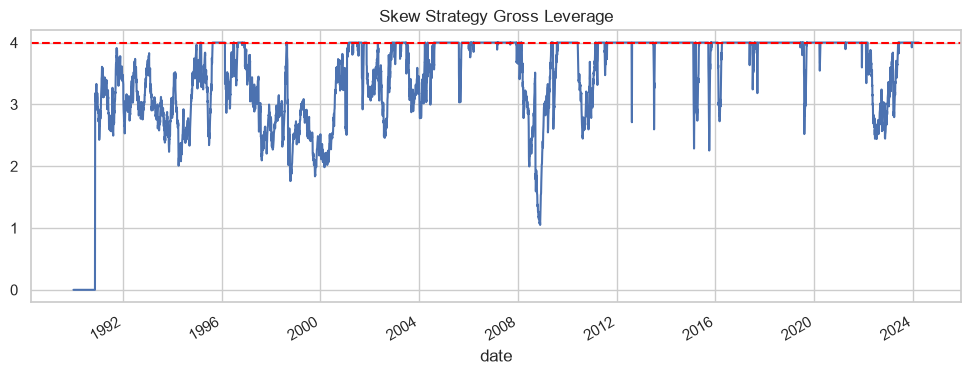

In [29]:
def calculate_positions(
    signal: pd.DataFrame,
    returns: pd.DataFrame,
) -> pd.DataFrame:

    annualized_volatility = (
        returns.ewm(
            span=35,
            min_periods=20,
        )
        .std()
        .shift(1)
        * np.sqrt(TRADING_DAYS)
    )

    raw_positions = (
        signal / annualized_volatility
    )

    estimated_portfolio_risk = np.sqrt(
        (
            raw_positions
            * annualized_volatility
        ).pow(2).sum(axis=1)
    )

    positions = raw_positions.mul(
        TARGET_VOLATILITY
        / estimated_portfolio_risk.replace(0, np.nan),
        axis=0,
    )

    gross_leverage = (
        positions.abs().sum(axis=1)
    )

    leverage_adjustment = (
        MAX_GROSS_LEVERAGE
        / gross_leverage.replace(0, np.nan)
    ).clip(upper=1)

    positions = positions.mul(
        leverage_adjustment,
        axis=0,
    )

    enough_markets = (
        signal.notna().sum(axis=1) >= 8
    )

    positions = (
        positions.where(enough_markets, 0)
        .fillna(0)
    )

    return positions


positions_126 = calculate_positions(
    signal_126,
    returns,
)

positions_252 = calculate_positions(
    signal_252,
    returns,
)

display(positions_252.tail())

gross_leverage = positions_252.abs().sum(axis=1)

print(gross_leverage.describe())

gross_leverage.plot(
    figsize=(12, 4),
    title="Skew Strategy Gross Leverage",
)

plt.axhline(
    MAX_GROSS_LEVERAGE,
    color="red",
    linestyle="--",
)

plt.show()

In [30]:
def run_backtest(
    desired_positions: pd.DataFrame,
    returns: pd.DataFrame,
    cost_bps: float,
) -> pd.DataFrame:

    # Prevent look-ahead bias.
    held_positions = (
        desired_positions.shift(1).fillna(0)
    )

    gross_return = (
        held_positions
        * returns.fillna(0)
    ).sum(axis=1)

    turnover = (
        held_positions.diff()
        .abs()
        .sum(axis=1)
        .fillna(0)
    )

    transaction_cost = (
        turnover * cost_bps / 10_000
    )

    net_return = (
        gross_return - transaction_cost
    )

    return pd.DataFrame({
        "gross_return": gross_return,
        "transaction_cost": transaction_cost,
        "net_return": net_return,
        "turnover": turnover,
    })


results_126 = run_backtest(
    positions_126,
    returns,
    BASELINE_COST_BPS,
)

results_252 = run_backtest(
    positions_252,
    returns,
    BASELINE_COST_BPS,
)

# Equal-weight the horizons rather than selecting the best one.
skew_return = pd.concat(
    [
        results_126["net_return"],
        results_252["net_return"],
    ],
    axis=1,
).mean(axis=1)

In [31]:
def performance_statistics(
    strategy_return: pd.Series,
    strategy_name: str,
) -> dict:

    strategy_return = strategy_return.dropna()

    active = strategy_return.ne(0)

    if active.any():
        first_active_date = active.idxmax()
        strategy_return = strategy_return.loc[first_active_date:]

    annual_return = (
        strategy_return.mean() * TRADING_DAYS
    )

    annual_volatility = (
        strategy_return.std(ddof=1)
        * np.sqrt(TRADING_DAYS)
    )

    sharpe = (
        annual_return / annual_volatility
        if annual_volatility > 0
        else np.nan
    )

    equity_curve = (
        1 + strategy_return
    ).cumprod()

    drawdown = (
        equity_curve
        / equity_curve.cummax()
        - 1
    )

    yearly_returns = (
        strategy_return
        .groupby(strategy_return.index.year)
        .sum()
    )

    yearly_test = stats.ttest_1samp(
        yearly_returns,
        popmean=0,
    )

    return {
        "strategy": strategy_name,
        "start": strategy_return.index.min(),
        "end": strategy_return.index.max(),
        "annual_return": annual_return,
        "annual_volatility": annual_volatility,
        "sharpe": sharpe,
        "max_drawdown": drawdown.min(),
        "positive_year_share": (
            yearly_returns > 0
        ).mean(),
        "yearly_p_value": yearly_test.pvalue,
    }


skew_statistics = performance_statistics(
    skew_return,
    "Skew ensemble",
)

display(
    pd.DataFrame([skew_statistics]).round(4)
)

C:\Users\jacob\AppData\Local\Temp\ipykernel_35172\720988075.py:71: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  pd.DataFrame([skew_statistics]).round(4)


,strategy,start,end,annual_return,annual_volatility,sharpe,max_drawdown,positive_year_share,yearly_p_value
0,Skew ensemble,1990-06-12,2024-03-28,0.0547,0.0981,0.5571,-0.2384,0.6857,0.0012


In [32]:
def calculate_trend_signal(
    returns: pd.DataFrame,
    lookback: int = 252,
) -> pd.DataFrame:

    trailing_return = returns.rolling(
        window=lookback,
        min_periods=int(lookback * 0.80),
    ).sum()

    return np.sign(trailing_return)


trend_signal = calculate_trend_signal(returns)

trend_positions = calculate_positions(
    trend_signal,
    returns,
)

trend_results = run_backtest(
    trend_positions,
    returns,
    BASELINE_COST_BPS,
)

trend_return = trend_results["net_return"]

combined_return = (
    0.5 * skew_return
    + 0.5 * trend_return
)

In [33]:
comparison = pd.DataFrame([
    performance_statistics(
        skew_return,
        "Skew",
    ),
    performance_statistics(
        trend_return,
        "Trend",
    ),
    performance_statistics(
        combined_return,
        "50% skew / 50% trend",
    ),
])

display(comparison.round(4))

comparison.to_csv(
    OUTPUTS / "strategy_comparison.csv",
    index=False,
)

strategy_correlation = pd.concat(
    [
        skew_return.rename("skew"),
        trend_return.rename("trend"),
    ],
    axis=1,
).corr()

display(strategy_correlation)

strategy_correlation.to_csv(
    OUTPUTS / "strategy_correlation.csv"
)

C:\Users\jacob\AppData\Local\Temp\ipykernel_35172\2543258691.py:16: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(comparison.round(4))


,strategy,start,end,annual_return,annual_volatility,sharpe,max_drawdown,positive_year_share,yearly_p_value
0,Skew,1990-06-12,2024-03-28,0.0547,0.0981,0.5571,-0.2384,0.6857,0.0012
1,Trend,1990-10-17,2024-03-28,0.0803,0.1248,0.6437,-0.2330,0.6857,0.0009
2,50% skew / 50% trend,1990-06-12,2024-03-28,0.0671,0.0829,0.8089,-0.1740,0.8000,0.0001


,skew,trend
skew,1.0000,0.1018
trend,0.1018,1.0000


In [34]:
periods = {
    "2000–2009": ("2000-01-01", "2009-12-31"),
    "2010–2019": ("2010-01-01", "2019-12-31"),
    "2020–present": ("2020-01-01", "2030-12-31"),
}

subperiod_rows = []

for period_name, dates in periods.items():
    start, end = dates

    period_return = skew_return.loc[start:end]

    row = performance_statistics(
        period_return,
        f"Skew: {period_name}",
    )

    row["period"] = period_name
    subperiod_rows.append(row)

subperiod_results = pd.DataFrame(
    subperiod_rows
)

display(subperiod_results.round(4))

subperiod_results.to_csv(
    OUTPUTS / "subperiod_results.csv",
    index=False,
)

C:\Users\jacob\AppData\Local\Temp\ipykernel_35172\2045690845.py:26: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(subperiod_results.round(4))


,strategy,start,end,annual_return,annual_volatility,sharpe,max_drawdown,positive_year_share,yearly_p_value,period
0,Skew: 2000–2009,2000-01-03,2009-12-31,0.0508,0.1151,0.4411,-0.2384,0.6,0.1130,2000–2009
1,Skew: 2010–2019,2010-01-04,2019-12-31,0.0461,0.0742,0.6213,-0.1452,0.8,0.0406,2010–2019
2,Skew: 2020–present,2020-01-01,2024-03-28,0.0668,0.0988,0.6759,-0.1778,0.8,0.4043,2020–present


In [35]:
cost_rows = []

for cost_bps in [0, 0.5, 1, 2, 5]:
    cost_result_126 = run_backtest(
        positions_126,
        returns,
        cost_bps,
    )

    cost_result_252 = run_backtest(
        positions_252,
        returns,
        cost_bps,
    )

    cost_adjusted_return = pd.concat(
        [
            cost_result_126["net_return"],
            cost_result_252["net_return"],
        ],
        axis=1,
    ).mean(axis=1)

    row = performance_statistics(
        cost_adjusted_return,
        f"Skew at {cost_bps} bp",
    )

    row["cost_bps"] = cost_bps
    cost_rows.append(row)

cost_results = pd.DataFrame(cost_rows)

display(
    cost_results[
        [
            "cost_bps",
            "annual_return",
            "annual_volatility",
            "sharpe",
            "max_drawdown",
            "yearly_p_value",
        ]
    ].round(4)
)

cost_results.to_csv(
    OUTPUTS / "cost_sensitivity.csv",
    index=False,
)

,cost_bps,annual_return,annual_volatility,sharpe,max_drawdown,yearly_p_value
0,0.0,0.0582,0.0981,0.5930,-0.2369,0.0006
1,0.5,0.0564,0.0981,0.5751,-0.2376,0.0009
2,1.0,0.0547,0.0981,0.5571,-0.2384,0.0012
3,2.0,0.0511,0.0981,0.5213,-0.2399,0.0022
4,5.0,0.0406,0.0981,0.4136,-0.2462,0.0121


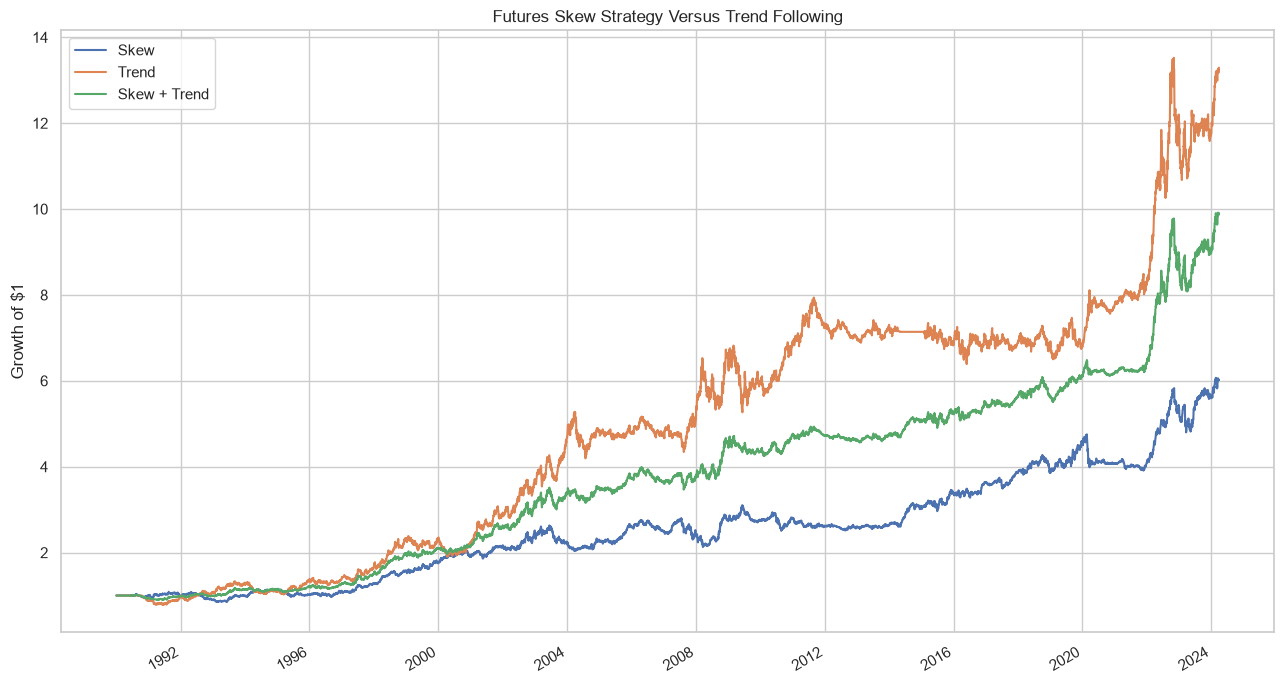

In [36]:
strategy_returns = pd.DataFrame({
    "Skew": skew_return,
    "Trend": trend_return,
    "Skew + Trend": combined_return,
})

equity_curves = (
    1 + strategy_returns
).cumprod()

ax = equity_curves.plot(
    figsize=(13, 7),
    linewidth=1.5,
)

ax.set_title(
    "Futures Skew Strategy Versus Trend Following"
)

ax.set_ylabel("Growth of $1")
ax.set_xlabel("")

plt.tight_layout()

plt.savefig(
    OUTPUTS / "equity_curves.png",
    dpi=200,
)

plt.show()

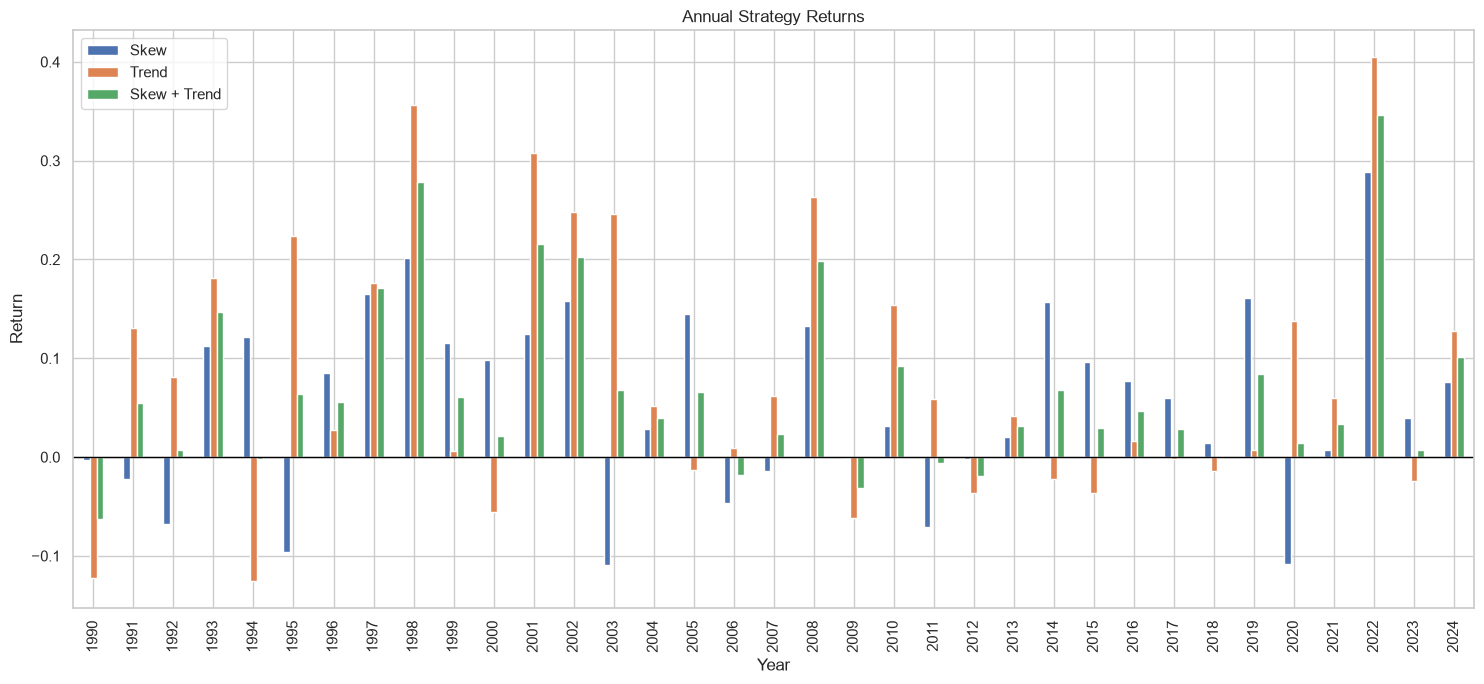

In [37]:
annual_returns = (
    strategy_returns
    .groupby(strategy_returns.index.year)
    .sum()
)

annual_returns.plot(
    kind="bar",
    figsize=(15, 7),
)

plt.title("Annual Strategy Returns")
plt.ylabel("Return")
plt.xlabel("Year")
plt.axhline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

In [38]:
skew_row = comparison.loc[
    comparison["strategy"] == "Skew"
].iloc[0]

trend_row = comparison.loc[
    comparison["strategy"] == "Trend"
].iloc[0]

combined_row = comparison.loc[
    comparison["strategy"]
    == "50% skew / 50% trend"
].iloc[0]

skew_trend_correlation = (
    strategy_correlation.loc["skew", "trend"]
)

positive_subperiods = (
    subperiod_results["annual_return"] > 0
).sum()

profitable_after_costs = (
    skew_row["annual_return"] > 0
)

acceptable_sharpe = (
    skew_row["sharpe"] >= 0.25
)

stable_subperiods = (
    positive_subperiods >= 2
)

diversifies_trend = (
    skew_trend_correlation < 0.30
)

improves_portfolio = (
    combined_row["sharpe"]
    > trend_row["sharpe"]
)

decision_table = pd.DataFrame({
    "Test": [
        "Positive after costs",
        "Sharpe at least 0.25",
        "Positive in at least two subperiods",
        "Correlation with trend below 0.30",
        "Combined Sharpe exceeds trend",
    ],
    "Passed": [
        profitable_after_costs,
        acceptable_sharpe,
        stable_subperiods,
        diversifies_trend,
        improves_portfolio,
    ],
})

display(decision_table)

if decision_table["Passed"].all():
    print("DECISION: Strong candidate for the LTG pitch.")
elif decision_table["Passed"].sum() >= 3:
    print("DECISION: Promising, but requires additional robustness testing.")
else:
    print("DECISION: Do not pitch this strategy in its current form.")

,Test,Passed
0,Positive after costs,True
1,Sharpe at least 0.25,True
2,Positive in at least two subperiods,True
3,Correlation with trend below 0.30,True
4,Combined Sharpe exceeds trend,True


DECISION: Strong candidate for the LTG pitch.


,strategy,annual_return,annual_volatility,sharpe,max_drawdown,positive_year_share,time_active,kill_switch_activations
0,Skew — original,0.0547,0.0981,0.5571,-0.2384,0.6857,1.0000,0
1,Skew — kill switch,0.0299,0.0797,0.3750,-0.2602,0.4857,0.6481,12



Kill-switch events:


,event_date,effective_date,event_type,reason,shadow_drawdown,shadow_annualized_volatility
0,1992-09-28,1992-09-29,Kill switch activated,Drawdown,-0.152328,0.072826
1,1993-09-07,1993-09-08,Strategy reactivated,Cooldown completed and risk conditions normalized,-0.069470,0.136354
2,1995-06-02,1995-06-05,Kill switch activated,Drawdown,-0.161064,0.154251
3,1996-11-25,1996-11-26,Strategy reactivated,Cooldown completed and risk conditions normalized,-0.065313,0.140200
4,2002-10-15,2002-10-16,Kill switch activated,Volatility,-0.059297,0.219587
5,2002-11-12,2002-11-13,Strategy reactivated,Cooldown completed and risk conditions normalized,-0.049761,0.142776
6,2003-01-02,2003-01-03,Kill switch activated,Volatility,-0.044472,0.211283
7,2003-01-31,2003-02-03,Strategy reactivated,Cooldown completed and risk conditions normalized,-0.037197,0.129237
8,2003-03-24,2003-03-25,Kill switch activated,Volatility,-0.053931,0.206528
9,2003-04-23,2003-04-24,Strategy reactivated,Cooldown completed and risk conditions normalized,-0.066726,0.149799


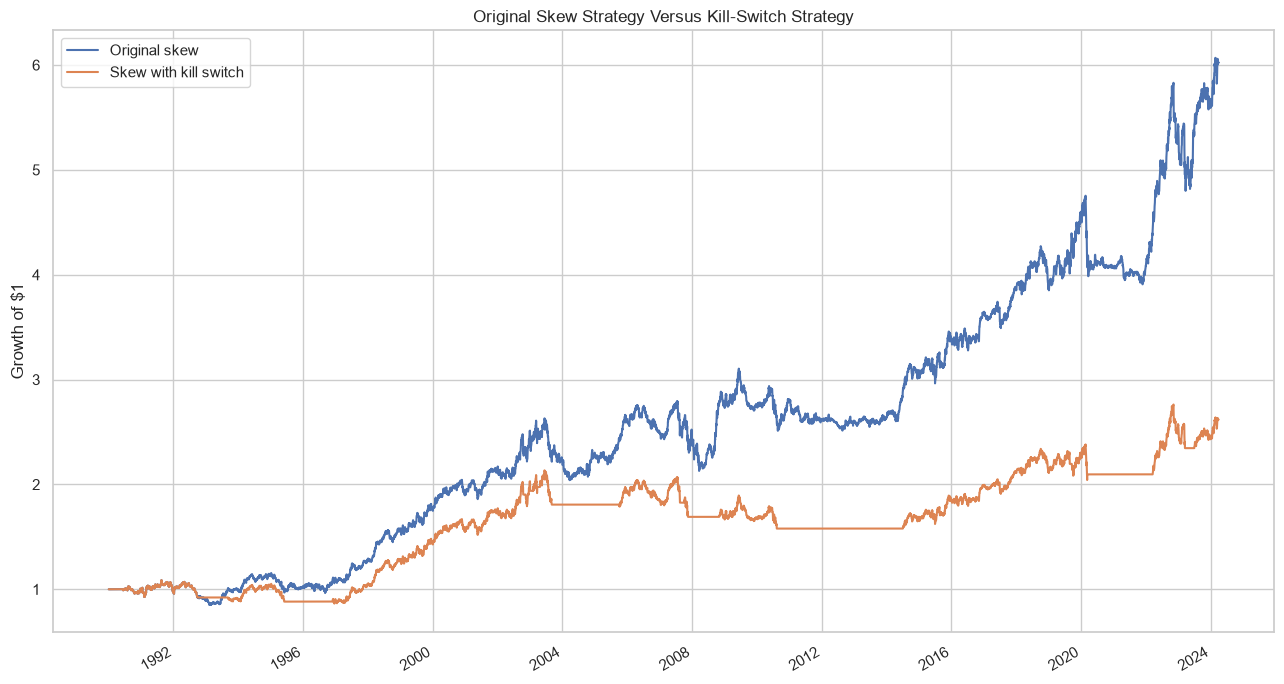


Kill-switch analysis saved to: c:\Users\jacob\OneDrive\Substack - Coding Folders\futures-skew-analysis\outputs


In [39]:
# ============================================================
# KILL-SWITCH BACKTEST
# Add this as a NEW CELL at the end of skew_analysis.ipynb
# ============================================================

KILL_SWITCH_DRAWDOWN = 0.15
KILL_SWITCH_VOLATILITY = 0.20
KILL_SWITCH_VOLATILITY_WINDOW = 20

KILL_SWITCH_COOLDOWN_DAYS = 20
KILL_SWITCH_REENTRY_VOLATILITY = 0.15
KILL_SWITCH_REENTRY_DRAWDOWN = 0.075


def run_kill_switch_backtest(
    position_models: dict[str, pd.DataFrame],
    market_returns: pd.DataFrame,
    shadow_returns: pd.Series,
    cost_bps: float,
    drawdown_limit: float = KILL_SWITCH_DRAWDOWN,
    volatility_limit: float = KILL_SWITCH_VOLATILITY,
    volatility_window: int = KILL_SWITCH_VOLATILITY_WINDOW,
    cooldown_days: int = KILL_SWITCH_COOLDOWN_DAYS,
    reentry_volatility: float = KILL_SWITCH_REENTRY_VOLATILITY,
    reentry_drawdown: float = KILL_SWITCH_REENTRY_DRAWDOWN,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    dates = market_returns.index
    columns = market_returns.columns

    returns_array = (
        market_returns
        .reindex(index=dates, columns=columns)
        .fillna(0.0)
        .to_numpy(dtype=float)
    )

    # Shift positions by one day to prevent look-ahead bias.
    held_position_models = {
        name: (
            positions
            .reindex(index=dates, columns=columns)
            .shift(1)
            .fillna(0.0)
            .to_numpy(dtype=float)
        )
        for name, positions in position_models.items()
    }

    previous_positions = {
        name: np.zeros(len(columns))
        for name in position_models
    }

    # The shadow strategy continues running while the live
    # strategy is disabled. It is used to determine re-entry.
    shadow_return_array = (
        shadow_returns
        .reindex(dates)
        .fillna(0.0)
        .to_numpy(dtype=float)
    )

    number_of_dates = len(dates)

    gross_returns = np.zeros(number_of_dates)
    transaction_costs = np.zeros(number_of_dates)
    net_returns = np.zeros(number_of_dates)
    turnovers = np.zeros(number_of_dates)

    active_during_day = np.zeros(
        number_of_dates,
        dtype=bool,
    )

    triggered_during_day = np.zeros(
        number_of_dates,
        dtype=bool,
    )

    shadow_drawdowns = np.zeros(number_of_dates)
    shadow_volatilities = np.full(
        number_of_dates,
        np.nan,
    )

    actual_equities = np.ones(number_of_dates)
    actual_drawdowns = np.zeros(number_of_dates)

    shadow_equity = 1.0
    shadow_peak = 1.0

    actual_equity = 1.0
    actual_peak = 1.0

    active_for_next_day = True
    cooldown_remaining = 0

    event_rows = []

    for date_number, current_date in enumerate(dates):

        active_today = active_for_next_day
        active_during_day[date_number] = active_today

        component_gross_returns = []
        component_costs = []
        component_turnovers = []

        for (
            model_name,
            normal_held_positions,
        ) in held_position_models.items():

            if active_today:
                current_positions = (
                    normal_held_positions[date_number].copy()
                )
            else:
                current_positions = np.zeros(
                    len(columns)
                )

            turnover = np.abs(
                current_positions
                - previous_positions[model_name]
            ).sum()

            gross_return = np.sum(
                current_positions
                * returns_array[date_number]
            )

            transaction_cost = (
                turnover
                * cost_bps
                / 10_000
            )

            component_gross_returns.append(
                gross_return
            )

            component_costs.append(
                transaction_cost
            )

            component_turnovers.append(
                turnover
            )

            previous_positions[model_name] = (
                current_positions
            )

        # Equal-weight the 126- and 252-day models,
        # matching the original strategy methodology.
        gross_returns[date_number] = np.mean(
            component_gross_returns
        )

        transaction_costs[date_number] = np.mean(
            component_costs
        )

        turnovers[date_number] = np.mean(
            component_turnovers
        )

        net_returns[date_number] = (
            gross_returns[date_number]
            - transaction_costs[date_number]
        )

        # Update actual invested portfolio.
        actual_equity *= (
            1.0 + net_returns[date_number]
        )

        actual_peak = max(
            actual_peak,
            actual_equity,
        )

        actual_drawdown = (
            actual_equity / actual_peak - 1.0
        )

        actual_equities[date_number] = (
            actual_equity
        )

        actual_drawdowns[date_number] = (
            actual_drawdown
        )

        # Update the shadow strategy, including while flat.
        shadow_equity *= (
            1.0
            + shadow_return_array[date_number]
        )

        shadow_peak = max(
            shadow_peak,
            shadow_equity,
        )

        shadow_drawdown = (
            shadow_equity / shadow_peak - 1.0
        )

        shadow_drawdowns[date_number] = (
            shadow_drawdown
        )

        start_number = max(
            0,
            date_number
            - volatility_window
            + 1,
        )

        volatility_sample = (
            shadow_return_array[
                start_number:date_number + 1
            ]
        )

        if len(volatility_sample) >= volatility_window:
            shadow_volatility = (
                np.std(
                    volatility_sample,
                    ddof=1,
                )
                * np.sqrt(TRADING_DAYS)
            )
        else:
            shadow_volatility = np.nan

        shadow_volatilities[date_number] = (
            shadow_volatility
        )

        next_date = (
            dates[date_number + 1]
            if date_number + 1 < number_of_dates
            else pd.NaT
        )

        # --------------------------------------------
        # Kill-switch trigger
        # --------------------------------------------

        drawdown_breach = (
            shadow_drawdown
            <= -drawdown_limit
        )

        volatility_breach = (
            np.isfinite(shadow_volatility)
            and shadow_volatility
            >= volatility_limit
        )

        if active_today and (
            drawdown_breach
            or volatility_breach
        ):

            if drawdown_breach and volatility_breach:
                trigger_reason = (
                    "Drawdown and volatility"
                )
            elif drawdown_breach:
                trigger_reason = "Drawdown"
            else:
                trigger_reason = "Volatility"

            active_for_next_day = False
            cooldown_remaining = cooldown_days

            triggered_during_day[
                date_number
            ] = True

            event_rows.append({
                "event_date": current_date,
                "effective_date": next_date,
                "event_type": "Kill switch activated",
                "reason": trigger_reason,
                "shadow_drawdown": shadow_drawdown,
                "shadow_annualized_volatility": (
                    shadow_volatility
                ),
            })

        # --------------------------------------------
        # Simulated re-entry rule
        # --------------------------------------------

        elif not active_today:

            cooldown_remaining = max(
                0,
                cooldown_remaining - 1,
            )

            drawdown_recovered = (
                shadow_drawdown
                >= -reentry_drawdown
            )

            volatility_recovered = (
                np.isfinite(shadow_volatility)
                and shadow_volatility
                <= reentry_volatility
            )

            if (
                cooldown_remaining == 0
                and drawdown_recovered
                and volatility_recovered
            ):

                active_for_next_day = True

                event_rows.append({
                    "event_date": current_date,
                    "effective_date": next_date,
                    "event_type": "Strategy reactivated",
                    "reason": (
                        "Cooldown completed and "
                        "risk conditions normalized"
                    ),
                    "shadow_drawdown": (
                        shadow_drawdown
                    ),
                    "shadow_annualized_volatility": (
                        shadow_volatility
                    ),
                })

            else:
                active_for_next_day = False

        else:
            active_for_next_day = True

    kill_switch_results = pd.DataFrame(
        {
            "gross_return": gross_returns,
            "transaction_cost": transaction_costs,
            "net_return": net_returns,
            "turnover": turnovers,
            "active_during_day": active_during_day,
            "kill_switch_triggered": triggered_during_day,
            "shadow_drawdown": shadow_drawdowns,
            "shadow_20d_annualized_volatility": (
                shadow_volatilities
            ),
            "actual_equity": actual_equities,
            "actual_drawdown": actual_drawdowns,
        },
        index=dates,
    )

    event_columns = [
        "event_date",
        "effective_date",
        "event_type",
        "reason",
        "shadow_drawdown",
        "shadow_annualized_volatility",
    ]

    kill_switch_events = pd.DataFrame(
        event_rows,
        columns=event_columns,
    )

    return (
        kill_switch_results,
        kill_switch_events,
    )


# Run the kill-switch model.
kill_switch_results, kill_switch_events = (
    run_kill_switch_backtest(
        position_models={
            "skew_126": positions_126,
            "skew_252": positions_252,
        },
        market_returns=returns,
        shadow_returns=skew_return,
        cost_bps=BASELINE_COST_BPS,
    )
)

skew_return_kill_switch = (
    kill_switch_results["net_return"]
)


# ============================================================
# PERFORMANCE COMPARISON
# ============================================================

baseline_statistics = performance_statistics(
    skew_return,
    "Skew — original",
)

kill_switch_statistics = performance_statistics(
    skew_return_kill_switch,
    "Skew — kill switch",
)

baseline_statistics["time_active"] = 1.0
baseline_statistics["kill_switch_activations"] = 0

kill_switch_statistics["time_active"] = (
    kill_switch_results[
        "active_during_day"
    ].mean()
)

kill_switch_statistics[
    "kill_switch_activations"
] = int(
    kill_switch_results[
        "kill_switch_triggered"
    ].sum()
)

kill_switch_comparison = pd.DataFrame(
    [
        baseline_statistics,
        kill_switch_statistics,
    ]
)

display(
    kill_switch_comparison[
        [
            "strategy",
            "annual_return",
            "annual_volatility",
            "sharpe",
            "max_drawdown",
            "positive_year_share",
            "time_active",
            "kill_switch_activations",
        ]
    ].round(4)
)

print("\nKill-switch events:")

if kill_switch_events.empty:
    print(
        "The kill switch was never activated."
    )
else:
    display(kill_switch_events)


# ============================================================
# SAVE RESULTS
# ============================================================

kill_switch_results.to_csv(
    OUTPUTS / "kill_switch_daily.csv",
    index_label="date",
)

kill_switch_events.to_csv(
    OUTPUTS / "kill_switch_events.csv",
    index=False,
)

kill_switch_comparison.to_csv(
    OUTPUTS / "kill_switch_comparison.csv",
    index=False,
)


# ============================================================
# EQUITY-CURVE COMPARISON
# ============================================================

kill_switch_equity_curves = pd.DataFrame({
    "Original skew": (
        1.0 + skew_return
    ).cumprod(),

    "Skew with kill switch": (
        1.0 + skew_return_kill_switch
    ).cumprod(),
})

ax = kill_switch_equity_curves.plot(
    figsize=(13, 7),
    linewidth=1.5,
)

ax.set_title(
    "Original Skew Strategy Versus Kill-Switch Strategy"
)

ax.set_ylabel("Growth of $1")
ax.set_xlabel("")

plt.tight_layout()

plt.savefig(
    OUTPUTS / "kill_switch_equity_curve.png",
    dpi=200,
)

plt.show()

print(
    "\nKill-switch analysis saved to:",
    OUTPUTS,
)